In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
from sklearn.model_selection import KFold
import random


/home/fnst/Desktop/shendabadi/whisper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Shemo Loading for Whisper

In [4]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')

In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []
lens = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                lens.append(round((len(audio_data)/16000)*2))
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [6]:
len(features)

2962

In [6]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [7]:
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [8]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 2958 2959 2960]
  Test:  index=[   7   12   29   30   32   43   44   45   51   56   63   67   70   73
   80   87   93   96  102  104  108  111  120  124  134  135  139  141
  144  149  152  162  168  170  173  174  175  177  178  183  184  188
  192  194  196  199  203  210  211  212  218  221  226  231  233  239
  246  251  254  256  257  270  272  282  283  289  291  296  298  309
  313  314  318  321  322  324  331  332  351  354  365  366  367  368
  387  393  402  407  408  410  411  414  415  420  422  423  430  432
  433  436  439  443  450  457  460  463  464  471  478  479  485  486
  495  498  506  507  509  511  521  527  528  532  533  535  543  544
  554  555  557  564  565  567  568  572  581  594  598  599  602  605
  610  612  637  642  644  650  651  670  676  677  678  679  685  693
  695  700  705  727  736  741  742  744  746  748  761  764  765  772
  781  783  785  789  807  809  811  817  819  829  838  839  840  842
  8

In [9]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [10]:
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

trainF1lens = [value for index, value in enumerate(lens) if index in train_index1]
trainF2lens = [value for index, value in enumerate(lens) if index in train_index2]
trainF3lens = [value for index, value in enumerate(lens) if index in train_index3]
trainF4lens = [value for index, value in enumerate(lens) if index in train_index4]
trainF5lens = [value for index, value in enumerate(lens) if index in train_index5]

trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

testF1lens = [value for index, value in enumerate(lens) if index in test_index1]
testF2lens = [value for index, value in enumerate(lens) if index in test_index2]
testF3lens = [value for index, value in enumerate(lens) if index in test_index3]
testF4lens = [value for index, value in enumerate(lens) if index in test_index4]
testF5lens = [value for index, value in enumerate(lens) if index in test_index5]

testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

In [11]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, lens, labels):
        self.features = features
        self.labels = labels
        self.lens = lens

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]]),  # Convert to PyTorch tensor if not already
            'len': torch.Tensor([self.lens[index]])
        }

        return sample


Fold1train = AudioDataSet(trainF1features, trainF1lens ,trainF1labels)
Fold1test = AudioDataSet(testF1features, testF1lens, testF1labels)

Fold2train = AudioDataSet(trainF2features, trainF2lens, trainF2labels)
Fold2test = AudioDataSet(testF2features, testF2lens, testF2labels)

Fold3train = AudioDataSet(trainF3features, trainF3lens, trainF3labels)
Fold3test = AudioDataSet(testF3features, testF3lens, testF3labels)

Fold4train = AudioDataSet(trainF4features, trainF4lens, trainF4labels)
Fold4test = AudioDataSet(testF4features, testF4lens, testF4labels)

Fold5train = AudioDataSet(trainF5features, trainF5lens, trainF5labels)
Fold5test = AudioDataSet(testF5features, testF5lens, testF5labels)



# Example of using DataLoader for batching
train_loaderF1 = DataLoader(Fold1train, batch_size=4, shuffle=True)
val_loaderF1 = DataLoader(Fold1test, batch_size=4, shuffle=False)

train_loaderF2 = DataLoader(Fold2train, batch_size=4, shuffle=True)
val_loaderF2 = DataLoader(Fold2test, batch_size=4, shuffle=False)

train_loaderF3 = DataLoader(Fold3train, batch_size=4, shuffle=True)
val_loaderF3 = DataLoader(Fold3test, batch_size=4, shuffle=False)

train_loaderF4 = DataLoader(Fold4train, batch_size=4, shuffle=True)
val_loaderF4 = DataLoader(Fold4test, batch_size=4, shuffle=False)

train_loaderF5 = DataLoader(Fold5train, batch_size=4, shuffle=True)
val_loaderF5 = DataLoader(Fold5test, batch_size=4, shuffle=False)

In [12]:
loader_lists = [(train_loaderF1, val_loaderF1), (train_loaderF2, val_loaderF2), (train_loaderF3, val_loaderF3), (train_loaderF4, val_loaderF4), (train_loaderF5, val_loaderF5)]

## Train Function for Whisper

In [15]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  best_val_accuracy = 0.0
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets, lens = batch['feature'], batch['label'].squeeze(-1).long(), batch['len'].squeeze(-1).long()
      inputs, targets, lens = inputs.to(device), targets.to(device), lens.to(device)
      output = model(inputs, lens)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output, lens = inputs.to('cpu'), targets.to('cpu'), output.to('cpu'), lens.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets ,lens = batch['feature'], batch['label'].squeeze(-1).long(), batch['len'].squeeze(-1).long()
      inputs, targets , lens = inputs.to(device), targets.to(device), lens.to(device)
      output = model(inputs, lens)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output, lens = inputs.to('cpu'), targets.to('cpu'), output.to('cpu'), lens.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)
    valid_accuracy = num_correct / num_examples

    print(f'Epoch: {epoch+1} finished in {duration:.4f} seconds, Training Loss: {training_loss: .4f}, Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy : .4f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        current_patience = 0
    else:
        current_patience += 1

    if valid_accuracy > best_val_accuracy:
      best_val_accuracy = valid_accuracy
      torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [16]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets ,lens = batch['feature'], batch['label'].squeeze(-1).long(), batch['len'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets , lens = inputs.to(device), targets.to(device), lens.to(device)
    output = model(inputs, lens)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output, lens = inputs.to('cpu'), targets.to('cpu'), output.to('cpu'), lens.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss} | U_Accuracy: {u_acc} | W_Accuracy: {w_acc} | Precision: {precision} | Recall: {recall} | f1: {f1}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Whisper Small attention scorer

In [14]:
reset_seed(42)

class WhisAttSumModel (nn.Module):
  def __init__(self):
    super(WhisAttSumModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.classifier = torch.nn.Linear(in_features=256, out_features=5)
    self.lenembed = nn.Embedding(num_embeddings=68, embedding_dim=256)

  def forward(self, x, len):
    lenemb = torch.unsqueeze(self.lenembed(len), dim=1)
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = torch.cat((out, lenemb), dim=1)
    out = self.layernorm(out)
    attention_scores = self.attention_scorer(out)
    attention_weights = F.softmax(attention_scores, dim=1)
    weighted_output = out*attention_weights
    weighted_mean_pooled_output = weighted_output.sum(dim=1)
    out = self.classifier(weighted_mean_pooled_output)

    return out

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 131.21 seconds, Training Loss:  0.86, Validation Loss: 0.63, Validation Accuracy:  0.78


Epoch: 2 finished in 131.62 seconds, Training Loss:  0.49, Validation Loss: 0.47, Validation Accuracy:  0.85


Epoch: 3 finished in 131.65 seconds, Training Loss:  0.40, Validation Loss: 0.47, Validation Accuracy:  0.83


Epoch: 4 finished in 131.63 seconds, Training Loss:  0.35, Validation Loss: 0.43, Validation Accuracy:  0.85


...

Epoch: 6 finished in 131.66 seconds, Training Loss:  0.27, Validation Loss: 0.44, Validation Accuracy:  0.85


Epoch: 7 finished in 131.68 seconds, Training Loss:  0.25, Validation Loss: 0.47, Validation Accuracy:  0.82


Epoch: 8 finished in 131.68 seconds, Training Loss:  0.21, Validation Loss: 0.46, Validation Accuracy:  0.83


Epoch: 9 finished in 131.69 seconds, Training Loss:  0.19, Validation Loss: 0.45, Validation Accuracy:  0.84


Epoch: 10 finished in 131.67 seconds, Training Loss:  0.17, Validation Loss: 0.49, Validation Accuracy:  0.83
Each epoch took 131.61 seconds in average.


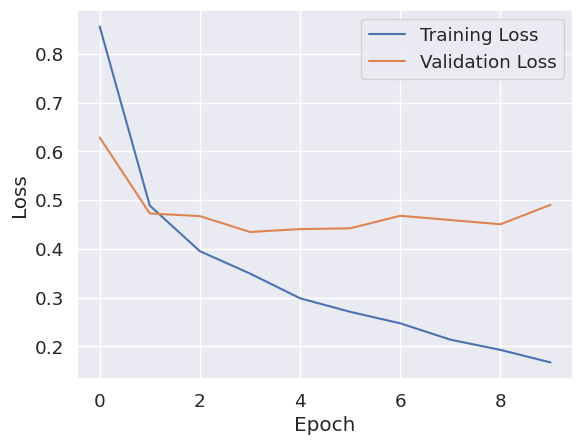

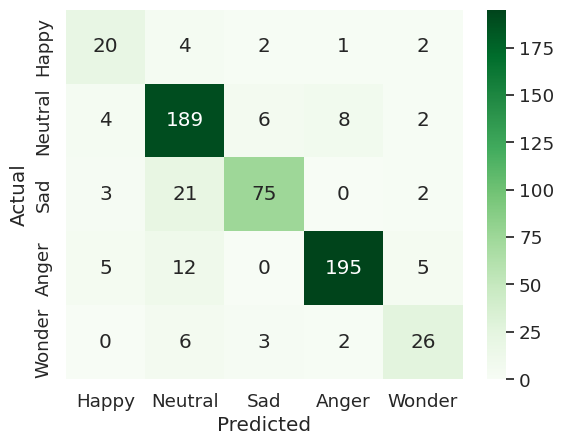

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.44 | U_Accuracy:  0.79 | W_Accuracy:  0.85 | Precision:  0.86 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.6896551724137931
Class 1: 0.9043062200956937
Class 2: 0.7425742574257426
Class 3: 0.8986175115207373
Class 4: 0.7027027027027027


Epoch: 1 finished in 131.71 seconds, Training Loss:  0.94, Validation Loss: 0.61, Validation Accuracy:  0.79


Epoch: 2 finished in 131.68 seconds, Training Loss:  0.51, Validation Loss: 0.49, Validation Accuracy:  0.82


Epoch: 3 finished in 131.65 seconds, Training Loss:  0.41, Validation Loss: 0.47, Validation Accuracy:  0.83


...

Epoch: 6 finished in 131.63 seconds, Training Loss:  0.28, Validation Loss: 0.46, Validation Accuracy:  0.83


Epoch: 7 finished in 131.64 seconds, Training Loss:  0.25, Validation Loss: 0.44, Validation Accuracy:  0.84


Epoch: 8 finished in 131.67 seconds, Training Loss:  0.23, Validation Loss: 0.50, Validation Accuracy:  0.82


Epoch: 9 finished in 131.68 seconds, Training Loss:  0.21, Validation Loss: 0.47, Validation Accuracy:  0.82


Epoch: 10 finished in 131.67 seconds, Training Loss:  0.18, Validation Loss: 0.49, Validation Accuracy:  0.83
Each epoch took 131.66 seconds in average.


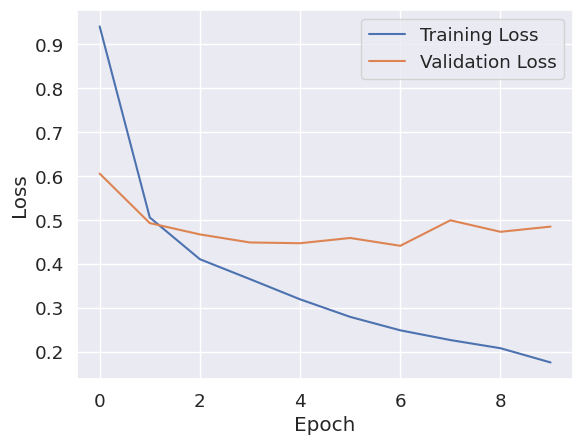

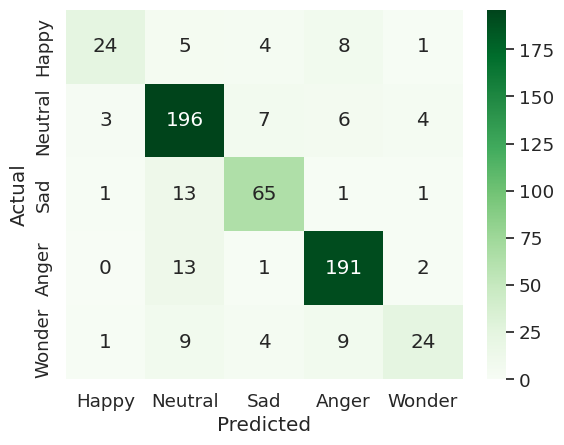

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.45 | U_Accuracy:  0.74 | W_Accuracy:  0.84 | Precision:  0.84 | Recall:  0.84 | f1:  0.84
Accuracy per class:
Class 0: 0.5714285714285714
Class 1: 0.9074074074074074
Class 2: 0.8024691358024691
Class 3: 0.9227053140096618
Class 4: 0.5106382978723404


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 131.72 seconds, Training Loss:  0.88, Validation Loss: 0.59, Validation Accuracy:  0.80


Epoch: 2 finished in 131.74 seconds, Training Loss:  0.48, Validation Loss: 0.56, Validation Accuracy:  0.80


...

Epoch: 6 finished in 131.70 seconds, Training Loss:  0.27, Validation Loss: 0.45, Validation Accuracy:  0.84


Epoch: 7 finished in 131.75 seconds, Training Loss:  0.23, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 8 finished in 131.67 seconds, Training Loss:  0.20, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 9 finished in 131.70 seconds, Training Loss:  0.18, Validation Loss: 0.46, Validation Accuracy:  0.85


Epoch: 10 finished in 131.75 seconds, Training Loss:  0.16, Validation Loss: 0.49, Validation Accuracy:  0.84
Each epoch took 131.72 seconds in average.


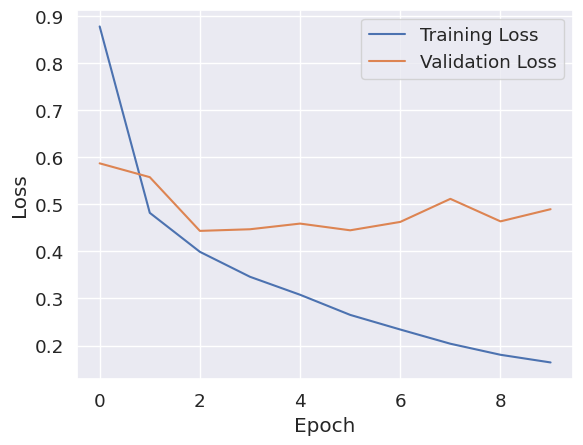

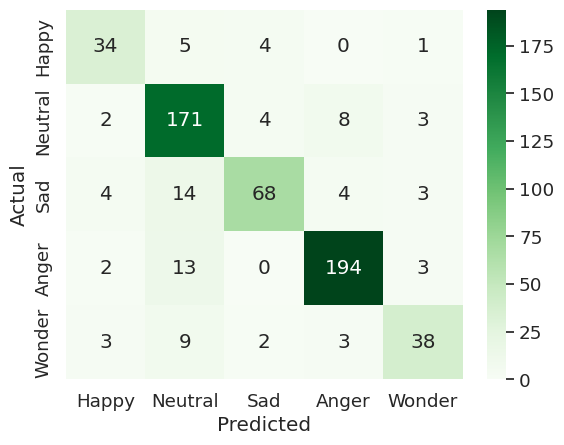

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.46 | U_Accuracy:  0.80 | W_Accuracy:  0.85 | Precision:  0.86 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.7727272727272727
Class 1: 0.9095744680851063
Class 2: 0.7311827956989247
Class 3: 0.9150943396226415
Class 4: 0.6909090909090909


Epoch: 1 finished in 131.72 seconds, Training Loss:  0.82, Validation Loss: 0.52, Validation Accuracy:  0.83


Epoch: 2 finished in 131.74 seconds, Training Loss:  0.48, Validation Loss: 0.45, Validation Accuracy:  0.87


Epoch: 3 finished in 131.70 seconds, Training Loss:  0.40, Validation Loss: 0.44, Validation Accuracy:  0.84


...

Epoch: 6 finished in 131.79 seconds, Training Loss:  0.27, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 7 finished in 131.74 seconds, Training Loss:  0.24, Validation Loss: 0.46, Validation Accuracy:  0.83


Epoch: 8 finished in 131.78 seconds, Training Loss:  0.21, Validation Loss: 0.51, Validation Accuracy:  0.81


Epoch: 9 finished in 131.75 seconds, Training Loss:  0.19, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 10 finished in 131.77 seconds, Training Loss:  0.17, Validation Loss: 0.52, Validation Accuracy:  0.81
Each epoch took 131.75 seconds in average.


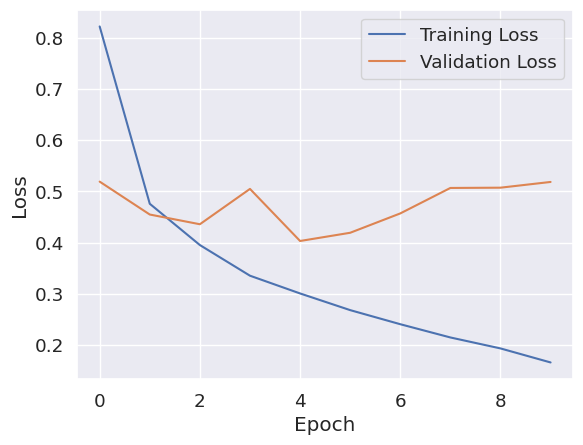

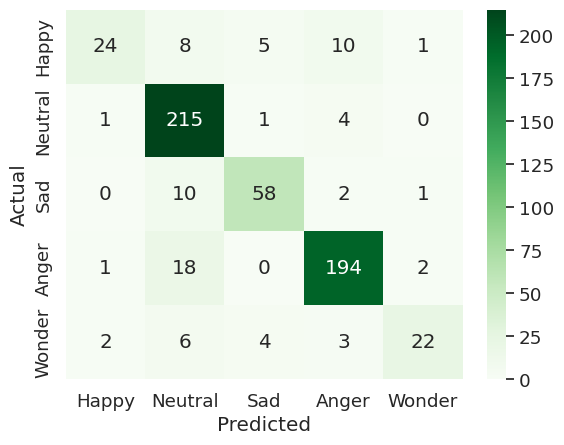

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.45 | U_Accuracy:  0.76 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.86
Accuracy per class:
Class 0: 0.5
Class 1: 0.9728506787330317
Class 2: 0.8169014084507042
Class 3: 0.9023255813953488
Class 4: 0.5945945945945946


Epoch: 1 finished in 131.65 seconds, Training Loss:  0.97, Validation Loss: 0.56, Validation Accuracy:  0.82


Epoch: 2 finished in 131.70 seconds, Training Loss:  0.53, Validation Loss: 0.46, Validation Accuracy:  0.86


Epoch: 3 finished in 131.67 seconds, Training Loss:  0.43, Validation Loss: 0.42, Validation Accuracy:  0.87


...

Epoch: 6 finished in 131.65 seconds, Training Loss:  0.30, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 7 finished in 131.64 seconds, Training Loss:  0.27, Validation Loss: 0.42, Validation Accuracy:  0.85


Epoch: 8 finished in 131.63 seconds, Training Loss:  0.24, Validation Loss: 0.38, Validation Accuracy:  0.87


Epoch: 9 finished in 131.57 seconds, Training Loss:  0.21, Validation Loss: 0.39, Validation Accuracy:  0.87


Epoch: 10 finished in 131.59 seconds, Training Loss:  0.19, Validation Loss: 0.42, Validation Accuracy:  0.86
Each epoch took 131.63 seconds in average.


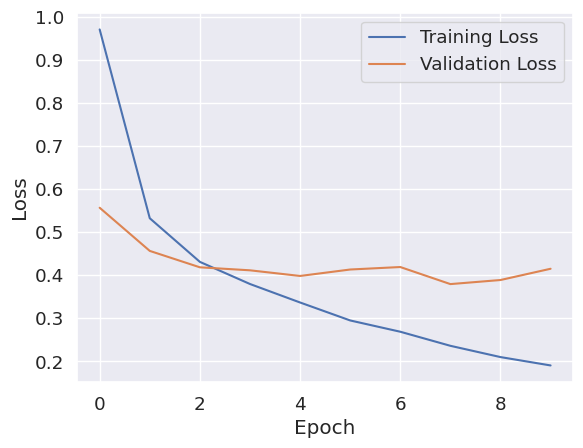

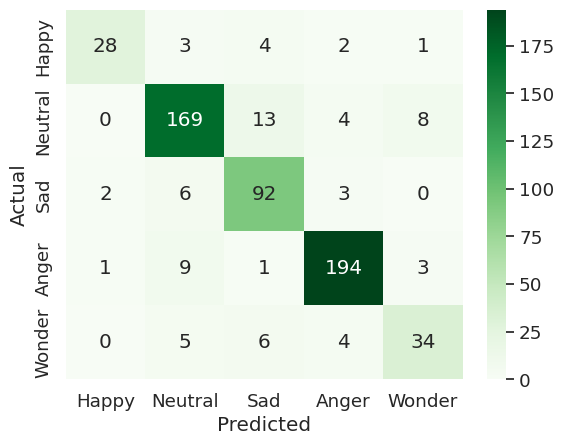

Testing finished with Loss:  0.40 | U_Accuracy:  0.83 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.87
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.8711340206185567
Class 2: 0.8932038834951457
Class 3: 0.9326923076923077
Class 4: 0.6938775510204082


In [48]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = WhisAttSumModel()

    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.attention_scorer.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requeres_grad = True

    for param in model.layernorm.parameters():
        param.requires_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    training_losses0, valid_losses0 = train(model, f'whisper_att_scorer_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'whisper_att_scorer_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)


# test attention with f4

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


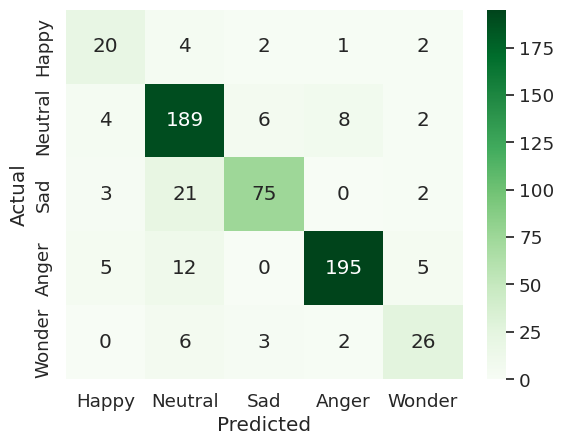

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4406962624107231 | U_Accuracy: 0.787571172831734 | W_Accuracy: 0.851602023608769 | Precision: 0.8564619692117087 | Recall: 0.851602023608769 | f1: 0.8520172265633126
Accuracy per class:
Class 0: 0.6896551724137931
Class 1: 0.9043062200956937
Class 2: 0.7425742574257426
Class 3: 0.8986175115207373
Class 4: 0.7027027027027027


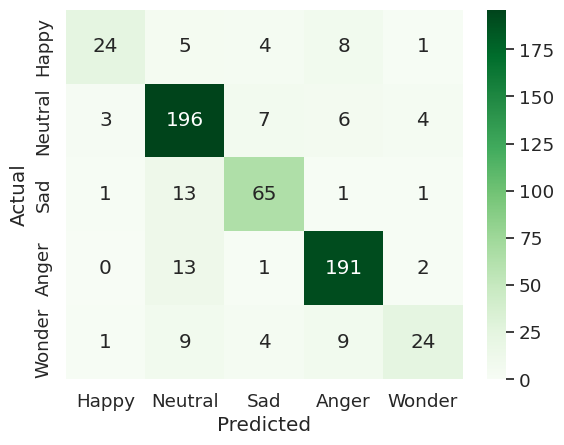

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.44921331621406463 | U_Accuracy: 0.74292974530409 | W_Accuracy: 0.8431703204047217 | Precision: 0.8402891643405459 | Recall: 0.8431703204047217 | f1: 0.8375344161387006
Accuracy per class:
Class 0: 0.5714285714285714
Class 1: 0.9074074074074074
Class 2: 0.8024691358024691
Class 3: 0.9227053140096618
Class 4: 0.5106382978723404


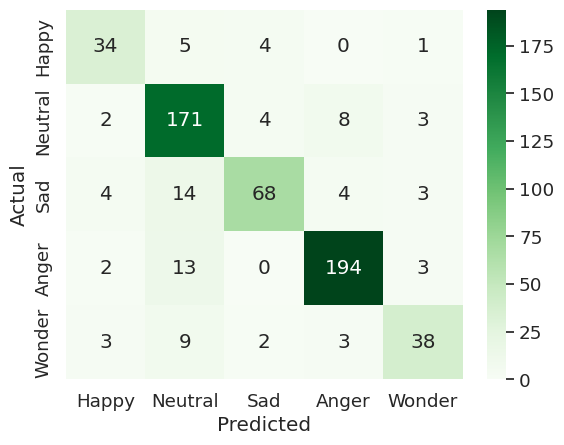

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.46403619481527525 | U_Accuracy: 0.8038975934086071 | W_Accuracy: 0.8530405405405406 | Precision: 0.8552182983398847 | Recall: 0.8530405405405406 | f1: 0.8518375623031869
Accuracy per class:
Class 0: 0.7727272727272727
Class 1: 0.9095744680851063
Class 2: 0.7311827956989247
Class 3: 0.9150943396226415
Class 4: 0.6909090909090909


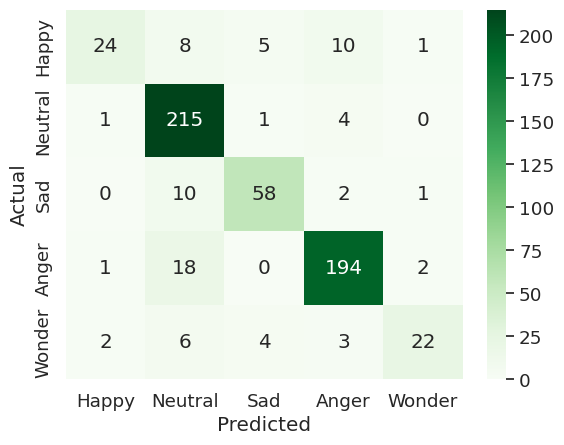

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4547073668171022 | U_Accuracy: 0.7573344526347359 | W_Accuracy: 0.8665540540540541 | Precision: 0.8677605366665252 | Recall: 0.8665540540540541 | f1: 0.8600049515421165
Accuracy per class:
Class 0: 0.5
Class 1: 0.9728506787330317
Class 2: 0.8169014084507042
Class 3: 0.9023255813953488
Class 4: 0.5945945945945946


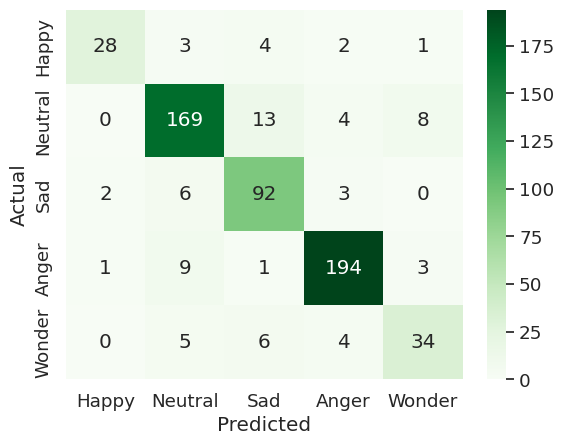

Testing finished with Loss: 0.39837921098680107 | U_Accuracy: 0.8255499736179154 | W_Accuracy: 0.8733108108108109 | Precision: 0.8748770977301056 | Recall: 0.8733108108108109 | f1: 0.8729665443479243
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.8711340206185567
Class 2: 0.8932038834951457
Class 3: 0.9326923076923077
Class 4: 0.6938775510204082


In [17]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = WhisAttSumModel().to(device)
    for param in model.parameters():
        param.requires_grad = False 
    model.load_state_dict(torch.load(f'whisper_att_scorer_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)

# multihead

In [18]:
reset_seed(42)

class WhisAttSumModelhead (nn.Module):
  def __init__(self, heads=2, dropout = 0.5, dimention=128):
    super(WhisAttSumModelhead, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    # self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.multihead = nn.MultiheadAttention(embed_dim=dimention, kdim=256, vdim=256, num_heads=heads, batch_first=True, dropout=dropout)
    self.classifier = torch.nn.Linear(in_features=dimention, out_features=5)
    self.attparam = nn.Parameter(torch.rand(1, dimention))
    self.lenembed = nn.Embedding(num_embeddings=68, embedding_dim=256)

  def forward(self, x, len):
    lenemb = torch.unsqueeze(self.lenembed(len), dim=1)
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = torch.cat((out, lenemb), dim=1)
    out = self.layernorm(out)
    stacked_param = self.attparam.unsqueeze(0).repeat(x.size()[0], 1, 1)
    weighted_output, attn_output_weights= self.multihead(query=stacked_param , key=out, value=out)
    out = self.classifier(weighted_output.squeeze(dim=1))

    return out

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 131.92 seconds, Training Loss:  0.87, Validation Loss: 0.58, Validation Accuracy:  0.81


Epoch: 2 finished in 131.89 seconds, Training Loss:  0.48, Validation Loss: 0.46, Validation Accuracy:  0.83


Epoch: 3 finished in 131.92 seconds, Training Loss:  0.37, Validation Loss: 0.45, Validation Accuracy:  0.84


Epoch: 4 finished in 131.95 seconds, Training Loss:  0.31, Validation Loss: 0.47, Validation Accuracy:  0.83


...

Epoch: 6 finished in 131.94 seconds, Training Loss:  0.21, Validation Loss: 0.45, Validation Accuracy:  0.85


Epoch: 7 finished in 131.97 seconds, Training Loss:  0.18, Validation Loss: 0.55, Validation Accuracy:  0.82


Epoch: 8 finished in 131.95 seconds, Training Loss:  0.14, Validation Loss: 0.50, Validation Accuracy:  0.84


Epoch: 9 finished in 131.95 seconds, Training Loss:  0.11, Validation Loss: 0.51, Validation Accuracy:  0.85


Epoch: 10 finished in 131.98 seconds, Training Loss:  0.09, Validation Loss: 0.52, Validation Accuracy:  0.84
Each epoch took 131.94 seconds in average.


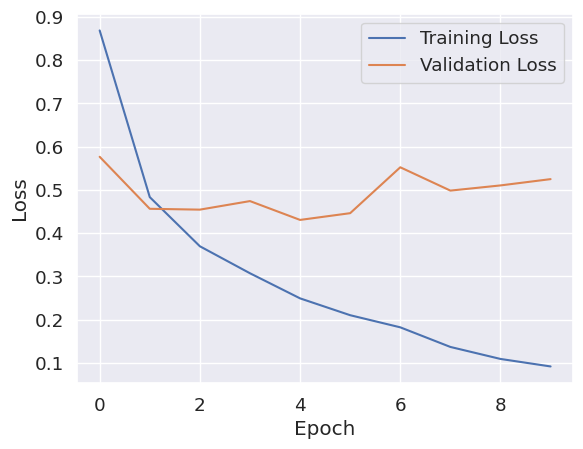

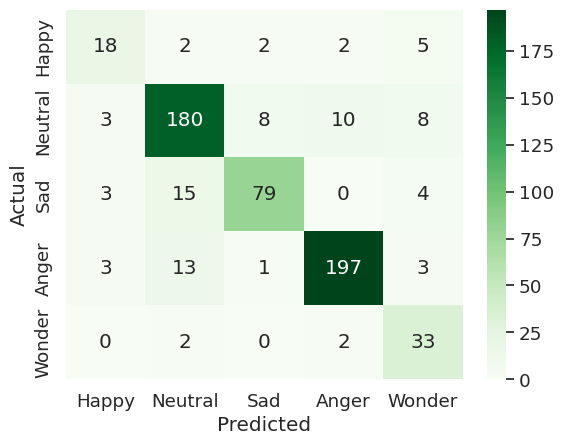

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.45 | U_Accuracy:  0.81 | W_Accuracy:  0.85 | Precision:  0.86 | Recall:  0.85 | f1:  0.86
Accuracy per class:
Class 0: 0.6206896551724138
Class 1: 0.861244019138756
Class 2: 0.7821782178217822
Class 3: 0.9078341013824884
Class 4: 0.8918918918918919


Epoch: 1 finished in 131.97 seconds, Training Loss:  0.84, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 2 finished in 131.95 seconds, Training Loss:  0.47, Validation Loss: 0.50, Validation Accuracy:  0.81


Epoch: 3 finished in 131.94 seconds, Training Loss:  0.39, Validation Loss: 0.49, Validation Accuracy:  0.82


...

Epoch: 6 finished in 131.97 seconds, Training Loss:  0.25, Validation Loss: 0.56, Validation Accuracy:  0.82


Epoch: 7 finished in 132.03 seconds, Training Loss:  0.22, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 8 finished in 131.99 seconds, Training Loss:  0.21, Validation Loss: 0.58, Validation Accuracy:  0.82


Epoch: 9 finished in 131.98 seconds, Training Loss:  0.18, Validation Loss: 0.53, Validation Accuracy:  0.83


Epoch: 10 finished in 131.99 seconds, Training Loss:  0.15, Validation Loss: 0.62, Validation Accuracy:  0.83
Each epoch took 131.96 seconds in average.


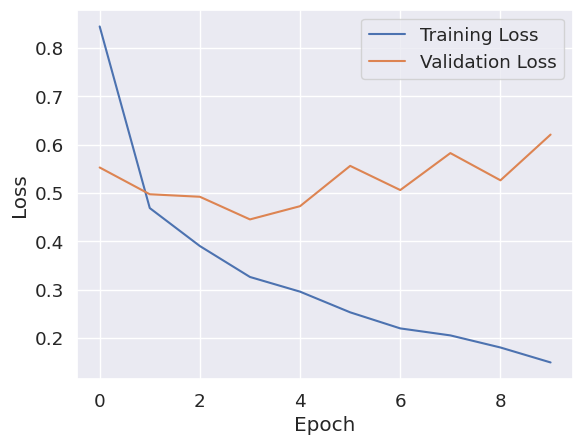

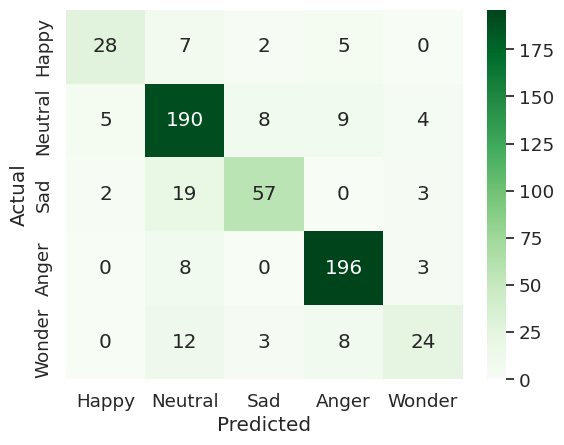

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.51 | U_Accuracy:  0.74 | W_Accuracy:  0.83 | Precision:  0.83 | Recall:  0.83 | f1:  0.83
Accuracy per class:
Class 0: 0.6666666666666666
Class 1: 0.8796296296296297
Class 2: 0.7037037037037037
Class 3: 0.9468599033816425
Class 4: 0.5106382978723404


Epoch: 1 finished in 131.92 seconds, Training Loss:  0.82, Validation Loss: 0.56, Validation Accuracy:  0.80


Epoch: 2 finished in 131.92 seconds, Training Loss:  0.48, Validation Loss: 0.57, Validation Accuracy:  0.81


Epoch: 3 finished in 131.97 seconds, Training Loss:  0.40, Validation Loss: 0.46, Validation Accuracy:  0.83


...

Epoch: 6 finished in 131.92 seconds, Training Loss:  0.23, Validation Loss: 0.46, Validation Accuracy:  0.85


Epoch: 7 finished in 131.90 seconds, Training Loss:  0.20, Validation Loss: 0.51, Validation Accuracy:  0.84


Epoch: 8 finished in 131.95 seconds, Training Loss:  0.17, Validation Loss: 0.54, Validation Accuracy:  0.83


Epoch: 9 finished in 131.99 seconds, Training Loss:  0.15, Validation Loss: 0.63, Validation Accuracy:  0.82


Epoch: 10 finished in 131.97 seconds, Training Loss:  0.12, Validation Loss: 0.61, Validation Accuracy:  0.83
Each epoch took 131.94 seconds in average.


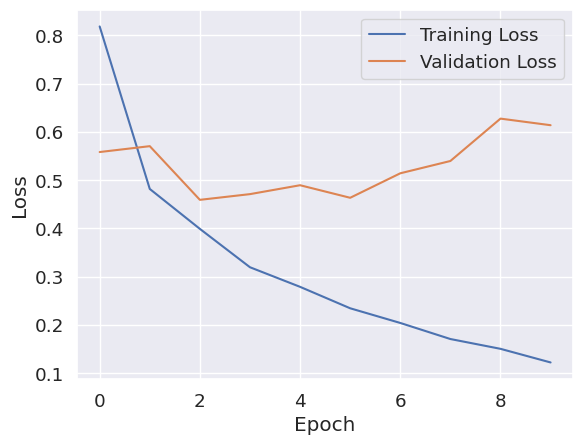

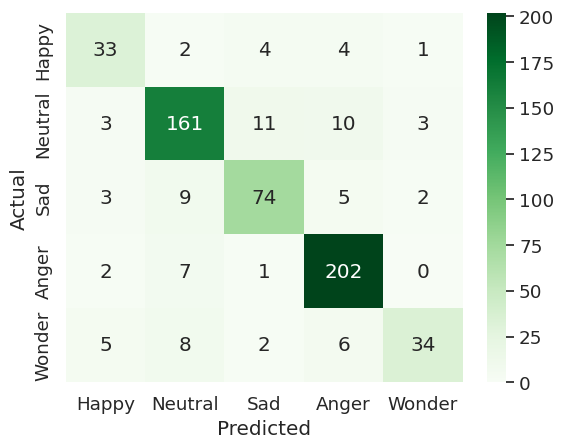

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.46 | U_Accuracy:  0.79 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.75
Class 1: 0.8563829787234043
Class 2: 0.7956989247311828
Class 3: 0.9528301886792453
Class 4: 0.6181818181818182


Epoch: 1 finished in 131.90 seconds, Training Loss:  0.85, Validation Loss: 0.54, Validation Accuracy:  0.82


Epoch: 2 finished in 131.89 seconds, Training Loss:  0.48, Validation Loss: 0.45, Validation Accuracy:  0.85


Epoch: 3 finished in 131.92 seconds, Training Loss:  0.38, Validation Loss: 0.38, Validation Accuracy:  0.87


...

Epoch: 6 finished in 131.93 seconds, Training Loss:  0.24, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 7 finished in 131.89 seconds, Training Loss:  0.19, Validation Loss: 0.47, Validation Accuracy:  0.87


Epoch: 8 finished in 131.87 seconds, Training Loss:  0.17, Validation Loss: 0.46, Validation Accuracy:  0.86


Epoch: 9 finished in 131.87 seconds, Training Loss:  0.15, Validation Loss: 0.48, Validation Accuracy:  0.87


Epoch: 10 finished in 131.84 seconds, Training Loss:  0.13, Validation Loss: 0.55, Validation Accuracy:  0.85
Each epoch took 131.89 seconds in average.


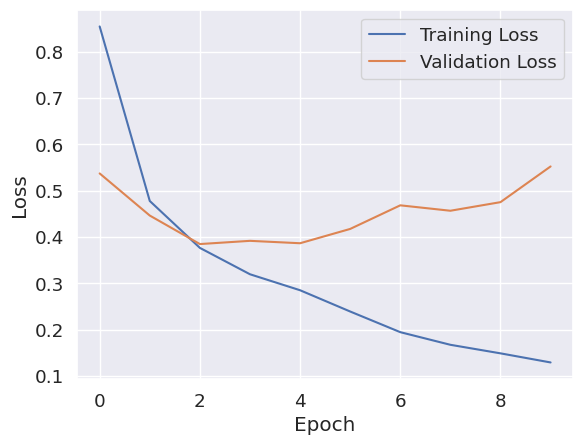

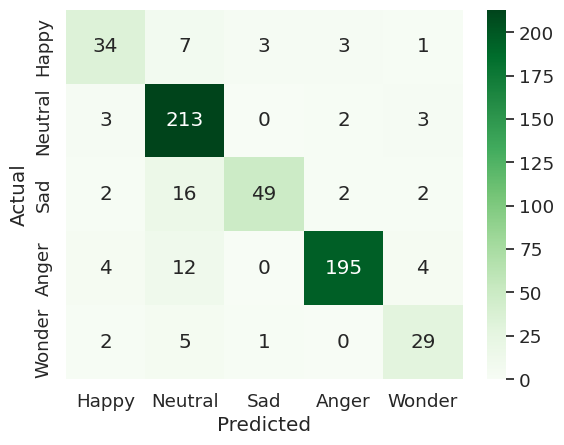

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss:  0.39 | U_Accuracy:  0.81 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7083333333333334
Class 1: 0.9638009049773756
Class 2: 0.6901408450704225
Class 3: 0.9069767441860465
Class 4: 0.7837837837837838


Epoch: 1 finished in 131.91 seconds, Training Loss:  0.90, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 2 finished in 131.90 seconds, Training Loss:  0.50, Validation Loss: 0.41, Validation Accuracy:  0.87


Epoch: 3 finished in 131.84 seconds, Training Loss:  0.40, Validation Loss: 0.37, Validation Accuracy:  0.86


...

Epoch: 6 finished in 131.89 seconds, Training Loss:  0.23, Validation Loss: 0.44, Validation Accuracy:  0.86


Epoch: 7 finished in 131.89 seconds, Training Loss:  0.18, Validation Loss: 0.40, Validation Accuracy:  0.88


Epoch: 8 finished in 131.88 seconds, Training Loss:  0.15, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 9 finished in 131.87 seconds, Training Loss:  0.13, Validation Loss: 0.54, Validation Accuracy:  0.84


Epoch: 10 finished in 131.91 seconds, Training Loss:  0.12, Validation Loss: 0.56, Validation Accuracy:  0.85
Each epoch took 131.89 seconds in average.


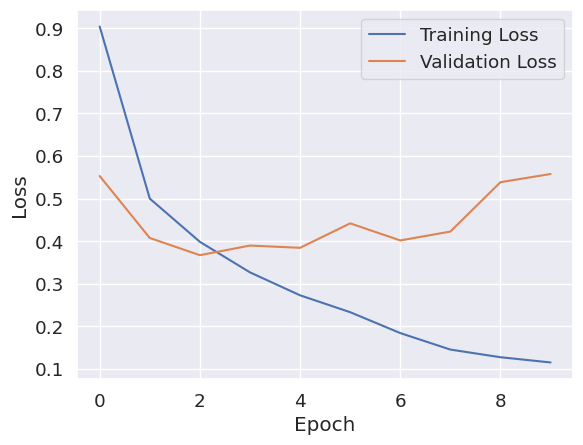

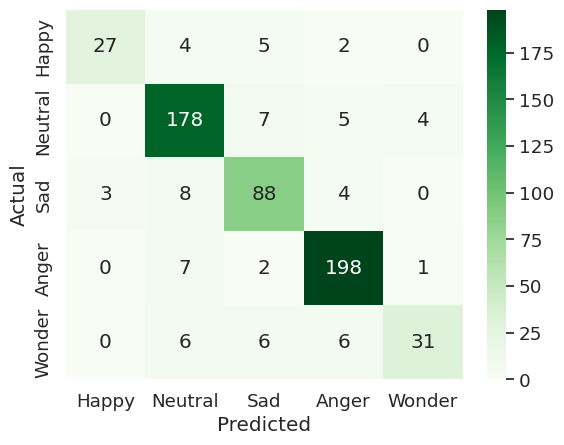

Testing finished with Loss:  0.39 | U_Accuracy:  0.81 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7105263157894737
Class 1: 0.9175257731958762
Class 2: 0.8543689320388349
Class 3: 0.9519230769230769
Class 4: 0.6326530612244898


In [50]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = WhisAttSumModelhead(heads=4, dropout=0.5)
    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.layernorm.parameters():
        param.requires_grad = True

    model.attparam.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    for param in model.multihead.parameters():
        param.requires_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    training_losses0, valid_losses0 = train(model, f'whisper_att_multih_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'whisper_att_multih_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)

# test multihead with f4

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


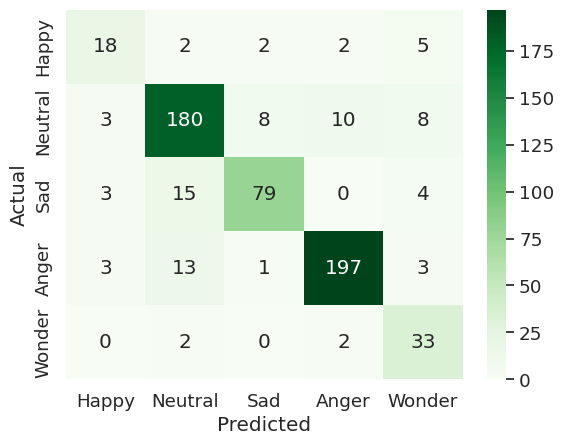

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4463012582433391 | U_Accuracy: 0.8127675770814665 | W_Accuracy: 0.8549747048903878 | Precision: 0.8618572523798008 | Recall: 0.8549747048903878 | f1: 0.8563321258120318
Accuracy per class:
Class 0: 0.6206896551724138
Class 1: 0.861244019138756
Class 2: 0.7821782178217822
Class 3: 0.9078341013824884
Class 4: 0.8918918918918919


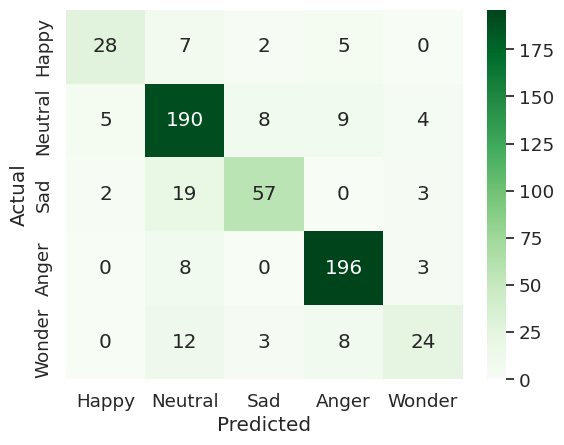

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.5060341080206121 | U_Accuracy: 0.7414996402507965 | W_Accuracy: 0.8347386172006745 | Precision: 0.8309308773579142 | Recall: 0.8347386172006745 | f1: 0.8297969704141869
Accuracy per class:
Class 0: 0.6666666666666666
Class 1: 0.8796296296296297
Class 2: 0.7037037037037037
Class 3: 0.9468599033816425
Class 4: 0.5106382978723404


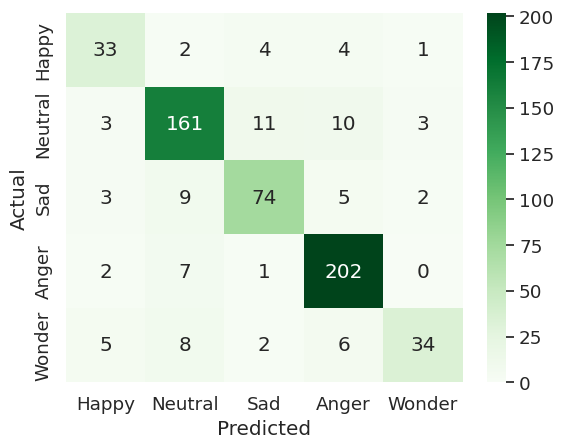

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.46348385028604017 | U_Accuracy: 0.7946187820631301 | W_Accuracy: 0.8513513513513513 | Precision: 0.8507305914917075 | Recall: 0.8513513513513513 | f1: 0.8489229238830005
Accuracy per class:
Class 0: 0.75
Class 1: 0.8563829787234043
Class 2: 0.7956989247311828
Class 3: 0.9528301886792453
Class 4: 0.6181818181818182


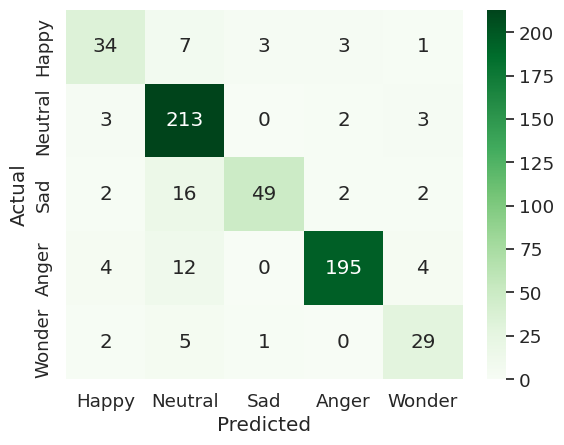

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.3864764842846607 | U_Accuracy: 0.8106071222701925 | W_Accuracy: 0.8783783783783784 | Precision: 0.8834962670633344 | Recall: 0.8783783783783784 | f1: 0.8769356577361864
Accuracy per class:
Class 0: 0.7083333333333334
Class 1: 0.9638009049773756
Class 2: 0.6901408450704225
Class 3: 0.9069767441860465
Class 4: 0.7837837837837838


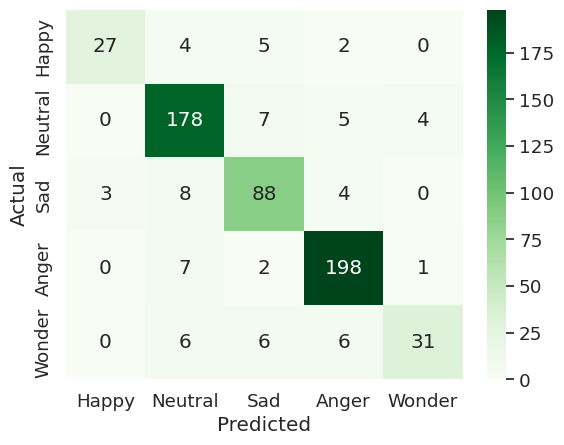

Testing finished with Loss: 0.38982713290936993 | U_Accuracy: 0.8133994318343504 | W_Accuracy: 0.8817567567567568 | Precision: 0.8817267451464524 | Recall: 0.8817567567567568 | f1: 0.8792575654960192
Accuracy per class:
Class 0: 0.7105263157894737
Class 1: 0.9175257731958762
Class 2: 0.8543689320388349
Class 3: 0.9519230769230769
Class 4: 0.6326530612244898


In [19]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = WhisAttSumModelhead(heads=4, dropout=0.5).to(device)
    for param in model.parameters():
        param.requires_grad = False  
    model.load_state_dict(torch.load(f'whisper_att_multih_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)